In [1]:
from pynhd import NLDI
import geopandas as gpd
import pandas as pd
from supporting_scripts import getData, SNOTEL_Analyzer, dataprocessing, mapping
from shapely.geometry import box, Polygon
import os
import datetime
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
#load combined dataframe
Hydro_DF = pd.read_csv(f'files/Hydro_Df/Hydro_Df', index_col=0, parse_dates=True)

Hydro_DF.head()

,site_no,flow_cms,565_SWE_cm,688_SWE_cm,Unnamed: 0,station_id,Average_Elevation_m,Minimum_Elevation_m,Maximum_Elevation_m,Average_Slope,...,"Developed,_Low_Intensity","Developed,_Medium_Intensity","Developed,_High_Intensity",Barren_Land_Rock_Sand_Clay,Deciduous_Forest,Evergreen_Forest,Shrub_Scrub,Grassland_Herbaceous,Woody_Wetlands,Emergent_Herbaceous_Wetlands
1980-10-01,9010500,0.453069,0.0,0.0,ColoradoRiverBasin,9010500,3200.7634,2659.6445,3941.0696,0.363304,...,0.076363,0.023496,0.017622,3.724154,0.105733,59.821429,18.708882,9.151786,2.267387,2.361372
1980-10-02,9010500,0.396435,0.0,0.0,ColoradoRiverBasin,9010500,3200.7634,2659.6445,3941.0696,0.363304,...,0.076363,0.023496,0.017622,3.724154,0.105733,59.821429,18.708882,9.151786,2.267387,2.361372
1980-10-03,9010500,0.368118,0.0,0.0,ColoradoRiverBasin,9010500,3200.7634,2659.6445,3941.0696,0.363304,...,0.076363,0.023496,0.017622,3.724154,0.105733,59.821429,18.708882,9.151786,2.267387,2.361372
1980-10-04,9010500,0.368118,0.0,0.0,ColoradoRiverBasin,9010500,3200.7634,2659.6445,3941.0696,0.363304,...,0.076363,0.023496,0.017622,3.724154,0.105733,59.821429,18.708882,9.151786,2.267387,2.361372
1980-10-05,9010500,0.368118,0.0,0.0,ColoradoRiverBasin,9010500,3200.7634,2659.6445,3941.0696,0.363304,...,0.076363,0.023496,0.017622,3.724154,0.105733,59.821429,18.708882,9.151786,2.267387,2.361372


# SWE Analysis

In [8]:
df_565 = pd.read_csv('files/SNOTEL_processed/565_CO_SNTL_processed.csv')
df_688 = pd.read_csv('files/SNOTEL_processed/688_CO_SNTL_processed.csv')

In [3]:
import os
if not os.path.exists('figures'):
    os.makedirs('figures')


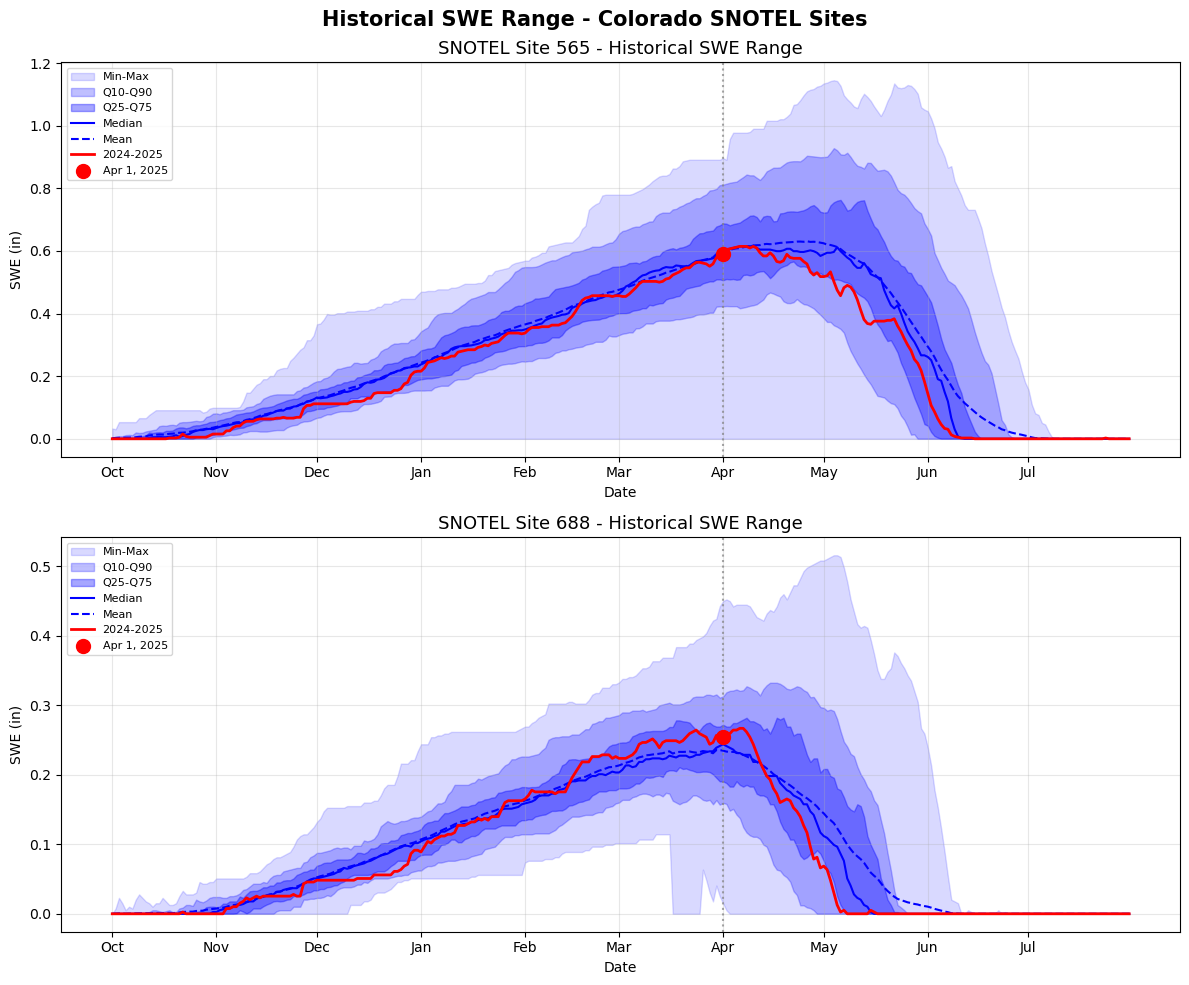

In [69]:
def plot_snotel_style_v2(df, site_name, ax):
    
    # Reset index so M-D becomes a regular column
    df = df.reset_index()
    
    x = range(len(df))
    
    # Plot shaded ranges
    ax.fill_between(x, df['min'], df['max'], alpha=0.15, color='blue', label='Min-Max')
    ax.fill_between(x, df['Q10'], df['Q90'], alpha=0.25, color='blue', label='Q10-Q90')
    ax.fill_between(x, df['Q25'], df['Q75'], alpha=0.35, color='blue', label='Q25-Q75')
    ax.plot(x, df['median'], color='blue', linewidth=1.5, label='Median')
    ax.plot(x, df['mean'], color='blue', linewidth=1.5, linestyle='--', label='Mean')
    
    # Plot 2025 water year
    ax.plot(x, df['2025_SWE_in'], color='red', linewidth=2, label='2024-2025')
    
    # Mark April 1st
    if '04-01' in df['M-D'].values:
        apr1_x = df[df['M-D'] == '04-01'].index[0]
        apr1_val = df.loc[apr1_x, '2025_SWE_in']
        if not pd.isna(apr1_val):
            ax.scatter(apr1_x, apr1_val, color='red', zorder=5, s=100, label='Apr 1, 2025')
            ax.axvline(x=apr1_x, color='gray', linestyle=':', alpha=0.7)
    
    # X axis ticks at each month
    tick_positions = []
    tick_labels = []
    for month, label in zip(['10', '11', '12', '01', '02', '03', '04', '05', '06', '07'],
                            ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul']):
        idx = df[df['M-D'].str.startswith(month)].index
        if len(idx) > 0:
            tick_positions.append(idx[0])
            tick_labels.append(label)
    
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_title(f'SNOTEL Site {site_name} - Historical SWE Range', fontsize=13)
    ax.set_ylabel('SWE (in)')
    ax.set_xlabel('Date')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

plot_snotel_style_v2(df_565, '565', axes[0])
plot_snotel_style_v2(df_688, '688', axes[1])

fig.suptitle('Historical SWE Range - Colorado SNOTEL Sites', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/SNOTEL_historical_range_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
for swe_col in ['565_SWE_cm', '688_SWE_cm']:
    # Get April 1st 2025 value
    apr1_val = df.loc['2025-04-01', swe_col]
    
    # Get historical stats for April 1st
    hist = df[df.index.strftime('%m-%d') == '04-01'][swe_col]
    hist_mean = hist.mean()
    hist_median = hist.median()
    
    print(f"\nSite: {swe_col}")
    print(f"Apr 1, 2025 SWE: {apr1_val:.2f} cm")
    print(f"Historical Mean: {hist_mean:.2f} cm")
    print(f"Historical Median: {hist_median:.2f} cm")
    print(f"% of Mean: {(apr1_val/hist_mean)*100:.1f}%")
    print(f"% of Median: {(apr1_val/hist_median)*100:.1f}%")


Site: 565_SWE_cm
Apr 1, 2025 SWE: 1.50 cm
Historical Mean: 1.54 cm
Historical Median: 1.52 cm
% of Mean: 97.8%
% of Median: 98.7%

Site: 688_SWE_cm
Apr 1, 2025 SWE: 0.65 cm
Historical Mean: 0.59 cm
Historical Median: 0.61 cm
% of Mean: 108.5%
% of Median: 105.3%


## Streamflow (TASK 3)

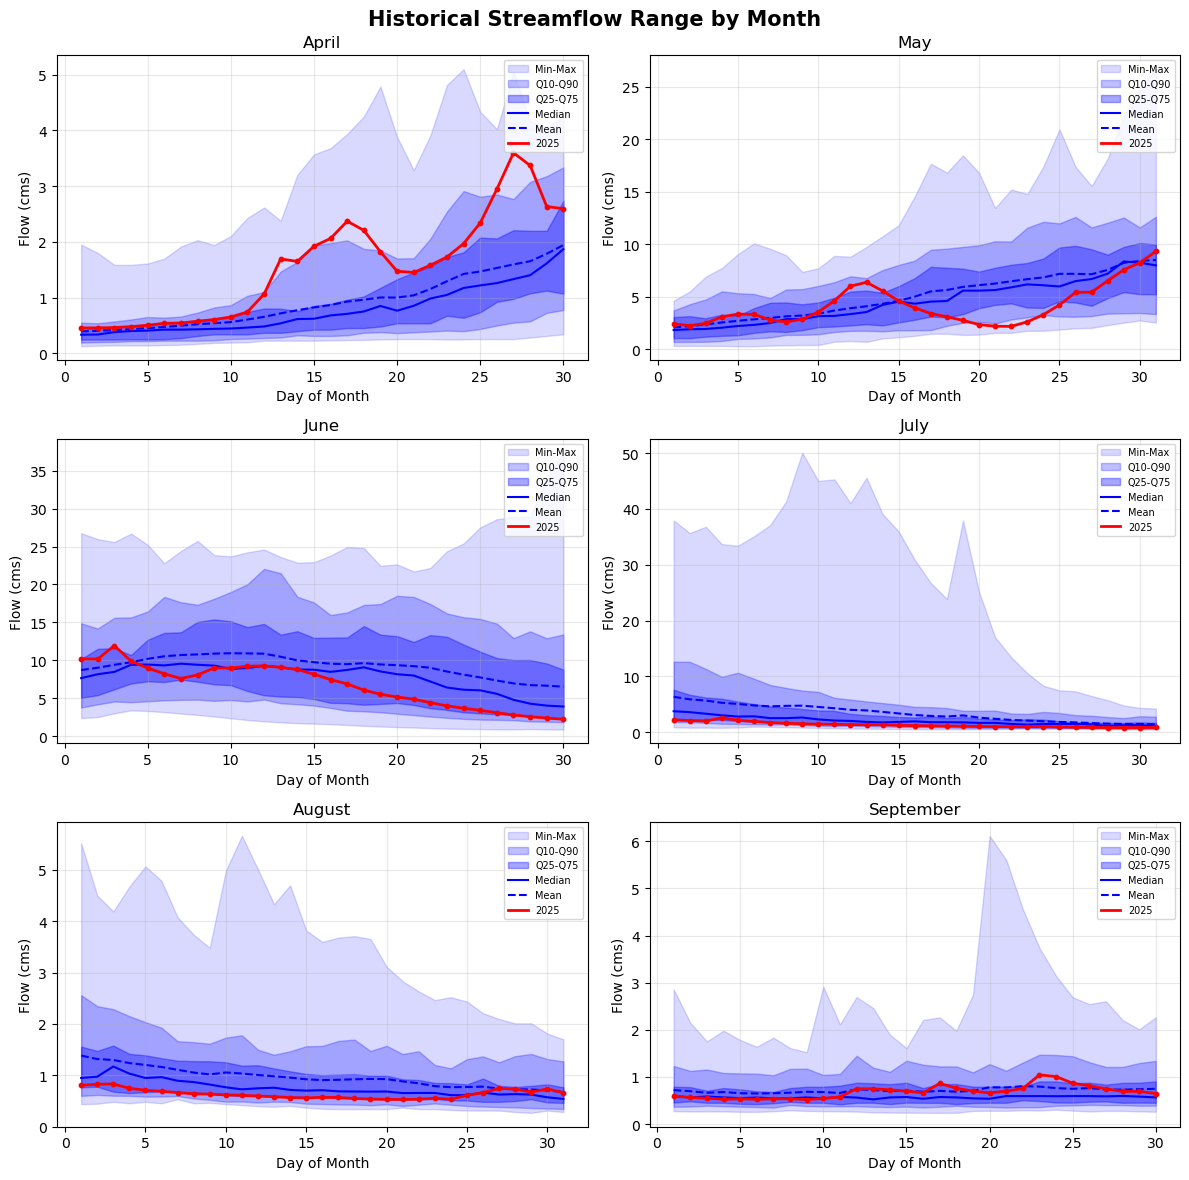

In [5]:

df = Hydro_DF

import matplotlib.pyplot as plt
import numpy as np

def plot_streamflow_historical(df, flow_col='flow_cms', ax=None, month_num=None, month_name=None):
    
    # Filter to the month of interest
    month_df = df[df.index.month == month_num].copy()
    month_df['D'] = month_df.index.day
    month_df['Year'] = month_df.index.year
    
    # Pivot so rows are days, columns are years
    pivoted = month_df.pivot_table(index='D', columns='Year', values=flow_col)
    
    # Calculate stats across years for each day
    stats = pd.DataFrame()
    stats['min'] = pivoted.min(axis=1)
    stats['Q10'] = pivoted.quantile(0.10, axis=1)
    stats['Q25'] = pivoted.quantile(0.25, axis=1)
    stats['mean'] = pivoted.mean(axis=1)
    stats['median'] = pivoted.median(axis=1)
    stats['Q75'] = pivoted.quantile(0.75, axis=1)
    stats['Q90'] = pivoted.quantile(0.90, axis=1)
    stats['max'] = pivoted.max(axis=1)
    
    x = stats.index  # day of month
    
    # Plot shaded ranges
    ax.fill_between(x, stats['min'], stats['max'], alpha=0.15, color='blue', label='Min-Max')
    ax.fill_between(x, stats['Q10'], stats['Q90'], alpha=0.25, color='blue', label='Q10-Q90')
    ax.fill_between(x, stats['Q25'], stats['Q75'], alpha=0.35, color='blue', label='Q25-Q75')
    ax.plot(x, stats['median'], color='blue', linewidth=1.5, label='Median')
    ax.plot(x, stats['mean'], color='blue', linewidth=1.5, linestyle='--', label='Mean')
    
    # Plot 2025
    if 2025 in pivoted.columns:
        ax.plot(x, pivoted[2025], color='red', linewidth=2, label='2025')
        ax.scatter(x, pivoted[2025], color='red', s=10, zorder=4)
    
    ax.set_title(month_name, fontsize=12)
    ax.set_ylabel('Flow (cms)')
    ax.set_xlabel('Day of Month')
    ax.legend(loc='upper right', fontsize=7)
    ax.grid(alpha=0.3)

# Months to plot
months = [(4, 'April'), (5, 'May'), (6, 'June'), 
          (7, 'July'), (8, 'August'), (9, 'September')]

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, (month_num, month_name) in enumerate(months):
    plot_streamflow_historical(df, flow_col='flow_cms', ax=axes[i], 
                                month_num=month_num, month_name=month_name)

fig.suptitle('Historical Streamflow Range by Month', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/streamflow_historical_range.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
for month_num, month_name in months:
    # Filter to month
    month_df = df[df.index.month == month_num].copy()
    month_df['D'] = month_df.index.day
    month_df['Year'] = month_df.index.year
    
    # Pivot
    pivoted = month_df.pivot_table(index='D', columns='Year', values='flow_cms')
    
    # Historical stats (excluding 2025)
    hist = pivoted.drop(columns=[2025], errors='ignore')
    hist_mean = hist.mean(axis=1).mean()
    hist_median = hist.median(axis=1).median()
    
    # 2025 monthly mean
    if 2025 in pivoted.columns:
        val_2025 = pivoted[2025].mean()
        print(f"\n{month_name}:")
        print(f"  2025 Mean Flow:      {val_2025:.3f} cms")
        print(f"  Historical Mean:     {hist_mean:.3f} cms")
        print(f"  Historical Median:   {hist_median:.3f} cms")
        print(f"  % of Mean:           {(val_2025/hist_mean)*100:.1f}%")
        print(f"  % of Median:         {(val_2025/hist_median)*100:.1f}%")
    else:
        print(f"\n{month_name}: No 2025 data available")


April:
  2025 Mean Flow:      1.549 cms
  Historical Mean:     0.916 cms
  Historical Median:   0.645 cms
  % of Mean:           169.1%
  % of Median:         240.2%

May:
  2025 Mean Flow:      4.136 cms
  Historical Mean:     5.072 cms
  Historical Median:   4.460 cms
  % of Mean:           81.6%
  % of Median:         92.7%

June:
  2025 Mean Flow:      6.757 cms
  Historical Mean:     9.314 cms
  Historical Median:   8.608 cms
  % of Mean:           72.5%
  % of Median:         78.5%

July:
  2025 Mean Flow:      1.309 cms
  Historical Mean:     3.410 cms
  Historical Median:   1.812 cms
  % of Mean:           38.4%
  % of Median:         72.2%

August:
  2025 Mean Flow:      0.637 cms
  Historical Mean:     0.965 cms
  Historical Median:   0.711 cms
  % of Mean:           66.0%
  % of Median:         89.6%

September:
  2025 Mean Flow:      0.686 cms
  Historical Mean:     0.716 cms
  Historical Median:   0.565 cms
  % of Mean:           95.7%
  % of Median:         121.4%


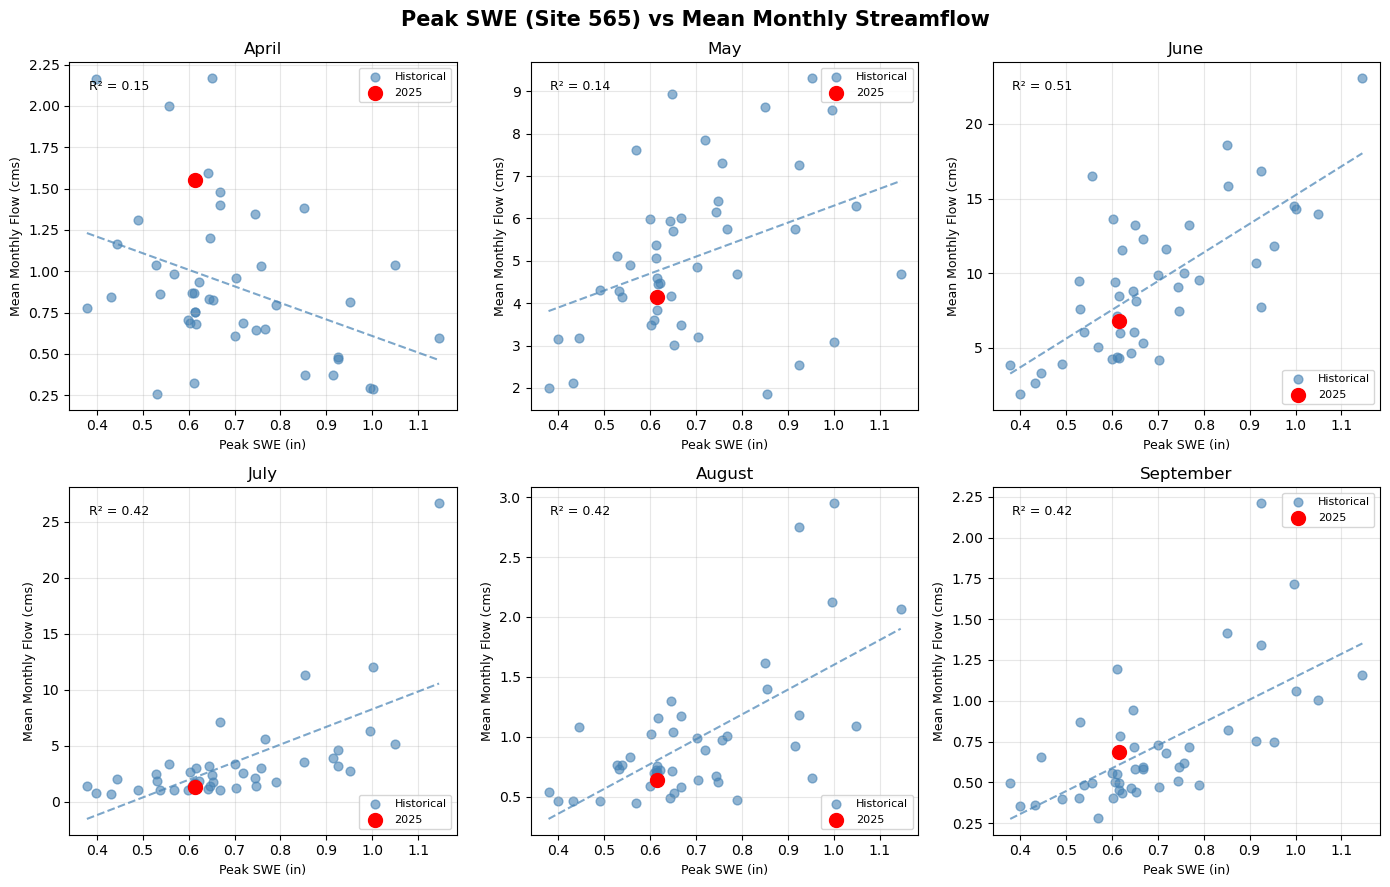

In [9]:
def get_peak_swe_by_year(df_snotel, swe_col='2025_SWE_in'):
    """Get peak SWE for each water year from the processed SNOTEL dataframe"""
    # Get all year columns
    year_cols = [col for col in df_snotel.columns if col.endswith('_SWE_in') and col[0].isdigit()]
    
    # For each year, get the peak SWE
    peak_swe = {}
    for col in year_cols:
        year = int(col.split('_')[0])
        peak_swe[year] = df_snotel[col].max()
    
    return pd.Series(peak_swe, name='peak_swe_in')

def get_monthly_flow_by_year(df, month_num, flow_col='flow_cms'):
    """Get mean monthly flow for each year"""
    month_df = df[df.index.month == month_num].copy()
    month_df['Year'] = month_df.index.year
    return month_df.groupby('Year')[flow_col].mean()

# Get peak SWE by year from site 565
peak_swe = get_peak_swe_by_year(df_565)

# Months to plot
months = [(4, 'April'), (5, 'May'), (6, 'June'),
          (7, 'July'), (8, 'August'), (9, 'September')]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i, (month_num, month_name) in enumerate(months):
    ax = axes[i]
    
    # Get monthly flow by year
    monthly_flow = get_monthly_flow_by_year(df, month_num)
    
    # Align the two series on year
    combined = pd.DataFrame({'peak_swe': peak_swe, 'flow': monthly_flow}).dropna()
    
    # Highlight 2025
    hist = combined[combined.index != 2025]
    yr2025 = combined[combined.index == 2025]
    
    # Scatter plot
    ax.scatter(hist['peak_swe'], hist['flow'], color='steelblue', alpha=0.6, s=40, label='Historical')
    if not yr2025.empty:
        ax.scatter(yr2025['peak_swe'], yr2025['flow'], color='red', s=100, zorder=5, label='2025')
    
    # Add trend line
    z = np.polyfit(hist['peak_swe'], hist['flow'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(hist['peak_swe'].min(), hist['peak_swe'].max(), 100)
    ax.plot(x_line, p(x_line), color='steelblue', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Add R² value
    correlation = hist['peak_swe'].corr(hist['flow'])
    ax.text(0.05, 0.95, f'R² = {correlation**2:.2f}', transform=ax.transAxes,
            fontsize=9, verticalalignment='top')
    
    ax.set_title(month_name, fontsize=12)
    ax.set_xlabel('Peak SWE (in)', fontsize=9)
    ax.set_ylabel('Mean Monthly Flow (cms)', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Peak SWE (Site 565) vs Mean Monthly Streamflow', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/peak_swe_vs_streamflow.png', dpi=150, bbox_inches='tight')
plt.show()